In [12]:
# 파이썬 유틸리티 함수 정의
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray

def plot_image(image, title=''):
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, size=20)

In [13]:
def SaltPepperNoise(im, percent):
    imTmp = im.copy()
    n = int(im.width * im.height * percent / 100)
    x = np.random.randint(0, im.width, n)
    y = np.random.randint(0, im.height, n)
    for (x,y) in zip(x,y):
        px = ( (0, 0, 0) if (np.random.rand() < 0.5) else (255, 255, 255) )
        imTmp.putpixel( (x,y), px)
    return imTmp

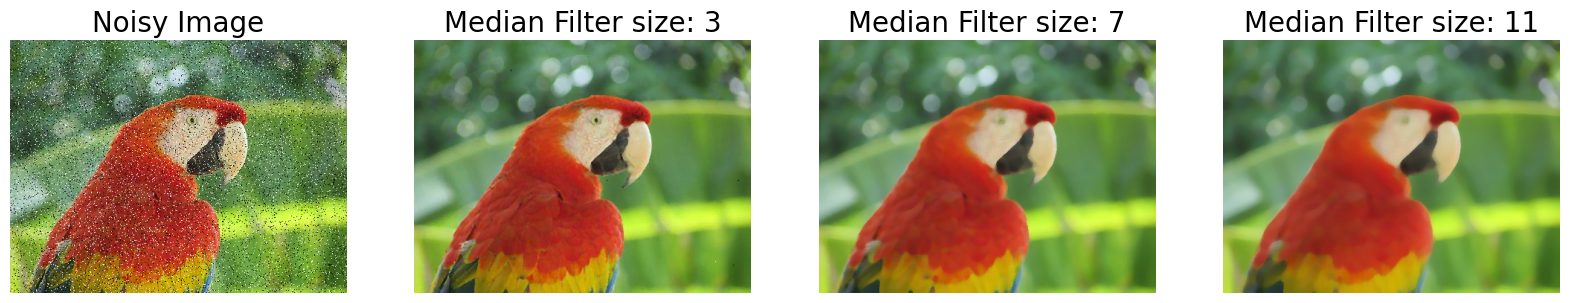

In [14]:
from PIL import Image, ImageFilter

imIn = Image.open("parrot.png")
imNoise = SaltPepperNoise(imIn, 10)

plt.figure(figsize=(20,10))
plt.subplot(141), plot_image(imNoise, 'Noisy Image')

i=2
for sz in [3,7,11]:
  imFiltered = imNoise.filter(ImageFilter.MedianFilter(size=sz))
  plt.subplot(1,4,i)
  plot_image(imFiltered, 'Median Filter size: ' + str(sz))
  i+=1
plt.show()

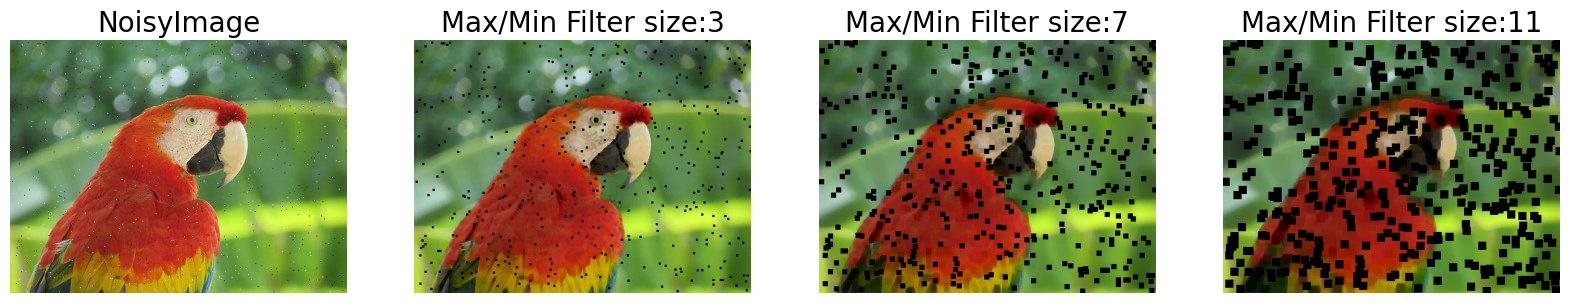

In [ ]:
from PIL import Image, ImageFilter

imIn = Image.open("parrot.png")
imNoise = SaltPepperNoise(imIn, 0.5)

plt.figure(figsize=(20,10))
plt.subplot(141), plot_image(imNoise, 'NoisyImage')

i=2
for sz in [3,7,11]:
  #imFiltered = imNoise.filter(ImageFilter.MaxFilter(size=sz))
  imFiltered = imNoise.filter(ImageFilter.MinFilter(size=sz))
  plt.subplot(1,4,i)
  plot_image(imFiltered, 'Max/Min Filter size:' + str(sz))
  i+=1
plt.show()

In [29]:
from skimage.restoration import denoise_bilateral, denoise_nl_means, estimate_sigma
from skimage import img_as_float
from skimage.util import random_noise
import numpy as np
!pip install PyWavelets

# add noise
parrot = img_as_float(imread('parrot.png'))
sigma = 0.25
noisy = random_noise(parrot, var=sigma**2)

# estimate standard deviation
sigma_est =estimate_sigma(noisy, average_sigmas=True, channel_axis=-1)

denoise_nlm = denoise_nl_means(noisy, patch_size=5, patch_distance=6, h=0.1,
                               fast_mode=True, sigma=0.8 * sigma_est,
                               channel_axis = -1)
denoise_bi = denoise_bilateral(noisy, sigma_color=0.1,
                               sigma_spatial=5, channel_axis=-1)

plt.figure(figsize=(15,10))
plt.subplot(221), plot_image(parrot, 'Origianl Image')
plt.subplot(222), plot_image(noisy, 'Noisy Image')
plt.subplot(223), plot_image(denoise_nlm, 'NLM Denoise Image')
plt.subplot(224), plot_image(denoise_bi, 'Bil Denoise Image')
plt.show()

Output hidden; open in https://colab.research.google.com to view.